# Analisis Regresi dan Korelasi Sederhana

**Nama:** Azriel Fajar Wicaksono  
**NIM:** 672025121

Notebook ini menganalisis hubungan antara **Persentase Penduduk Miskin (P0)** dan **Indeks Kedalaman Kemiskinan (P1)** per provinsi di Indonesia.

Isi:
1. Analisis korelasi (koefisien korelasi Pearson)
2. Regresi linear sederhana (`scipy` dan `sklearn`)
3. Visualisasi hubungan antar variabel

**Sumber data:** Portal Satu Data Indonesia (data.go.id) - Data Persentase Penduduk Miskin, Indeks Kedalaman, dan Indeks Keparahan Kemiskinan Menurut Provinsi di Indonesia.

## 1. Import Library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


## 2. Memuat Data

Data berformat *long* (kolom `klasifikasi` berisi P0/P1/P2). Kita ubah ke *wide* dengan `pivot_table` supaya P0, P1, P2 menjadi kolom terpisah per provinsi per tahun.

In [ ]:
# encoding utf-8-sig membuang BOM di awal file
raw = pd.read_csv('data_kemiskinan_provinsi.csv', encoding='utf-8-sig')
raw['provinsi'] = raw['provinsi'].str.strip()
raw.head()

,periode_data,tahun,provinsi,klasifikasi,persentase
0,2014,2013,Aceh,P0,17.72
1,2014,2013,Aceh,P1,3.20
2,2014,2013,Aceh,P2,0.83
3,2014,2013,Sumatera Utara,P0,10.39
4,2014,2013,Sumatera Utara,P1,1.72


In [ ]:
# Pivot: long -> wide
df = raw.pivot_table(index=['tahun', 'provinsi'],
                     columns='klasifikasi',
                     values='persentase').reset_index()
df.columns.name = None

# P0 = persentase penduduk miskin, P1 = indeks kedalaman, P2 = indeks keparahan
print(f"Jumlah baris data: {len(df)}")
df.head()

Jumlah baris data: 66


,tahun,provinsi,P0,P1,P2
0,2013,Aceh,17.72,3.20,0.83
1,2013,Bali,4.49,0.70,0.16
2,2013,Banten,5.89,1.02,0.29
3,2013,Bengkulu,17.75,3.24,0.89
4,2013,DI Yogyakarta,15.03,2.13,0.46


## 3. Analisis Korelasi

Kita uji hubungan antara **P0** (persentase penduduk miskin) sebagai variabel bebas (X) dan **P1** (indeks kedalaman kemiskinan) sebagai variabel terikat (Y).

In [ ]:
# Koefisien korelasi Pearson (r) dan p-value
r, p_value = stats.pearsonr(df['P0'], df['P1'])

print(f"Koefisien korelasi Pearson (r): {r:.4f}")
print(f"P-value: {p_value:.6e}")

if p_value < 0.05:
    print("=> Korelasi signifikan secara statistik (p < 0.05)")
else:
    print("=> Tidak signifikan secara statistik (p >= 0.05)")

Koefisien korelasi Pearson (r): 0.9736
P-value: 8.693872e-43
=> Korelasi signifikan secara statistik (p < 0.05)


In [ ]:
# Matriks korelasi antar semua variabel numerik
corr_matrix = df[['P0', 'P1', 'P2']].corr()
corr_matrix

,P0,P1,P2
P0,1.000000,0.973617,0.932105
P1,0.973617,1.000000,0.988388
P2,0.932105,0.988388,1.000000


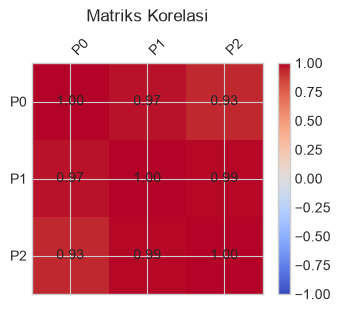

In [ ]:
# Visualisasi matriks korelasi sebagai heatmap
fig, ax = plt.subplots(figsize=(4, 3))
cax = ax.matshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='left')
ax.set_yticklabels(corr_matrix.columns)
for (i, j), val in np.ndenumerate(corr_matrix.values):
    ax.text(j, i, f'{val:.2f}', ha='center', va='center')
plt.title('Matriks Korelasi', pad=30)
plt.show()

## 4. Regresi Linear Sederhana

In [ ]:
X = df[['P0']]   # variabel bebas (2D)
y = df['P1']     # variabel terikat (1D)

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

print(f"Intercept (b0): {model.intercept_:.4f}")
print(f"Slope (b1): {model.coef_[0]:.4f}")
print(f"Persamaan regresi: P1 = {model.intercept_:.4f} + {model.coef_[0]:.4f} * P0")
print()
print(f"R-squared: {r2_score(y, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y, y_pred)):.4f}")

Intercept (b0): -0.5863
Slope (b1): 0.2176
Persamaan regresi: P1 = -0.5863 + 0.2176 * P0

R-squared: 0.9479
RMSE: 0.3144


### Alternatif: menggunakan `scipy.stats.linregress`

In [ ]:
slope, intercept, r_value, p_value, std_err = stats.linregress(df['P0'], df['P1'])

print(f"Slope: {slope:.4f}")
print(f"Intercept: {intercept:.4f}")
print(f"R-value: {r_value:.4f}")
print(f"R-squared: {r_value**2:.4f}")
print(f"P-value: {p_value:.6e}")
print(f"Standard error: {std_err:.4f}")

Slope: 0.2176
Intercept: -0.5863
R-value: 0.9736
R-squared: 0.9479
P-value: 8.693872e-43
Standard error: 0.0064


## 5. Visualisasi: Scatter Plot dengan Garis Regresi

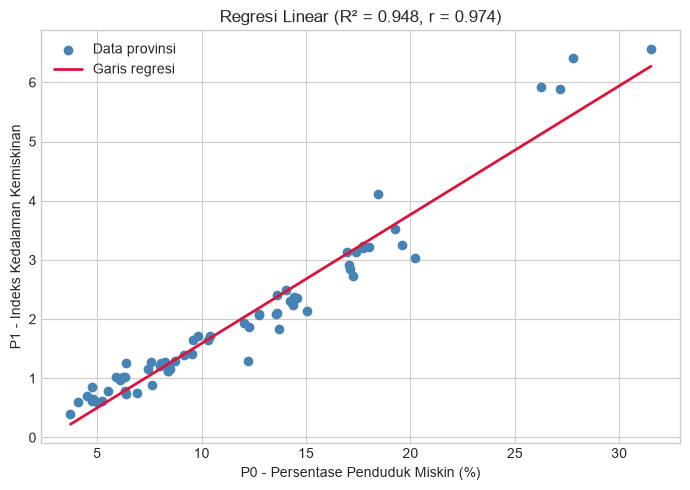

In [ ]:
# Urutkan berdasarkan P0 supaya garis regresi mulus
order = df['P0'].argsort()

plt.figure(figsize=(7, 5))
plt.scatter(df['P0'], df['P1'], color='steelblue', label='Data provinsi')
plt.plot(df['P0'].values[order], y_pred[order], color='crimson', linewidth=2, label='Garis regresi')
plt.xlabel('P0 - Persentase Penduduk Miskin (%)')
plt.ylabel('P1 - Indeks Kedalaman Kemiskinan')
plt.title(f'Regresi Linear (R\u00b2 = {r2_score(y, y_pred):.3f}, r = {r:.3f})')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Prediksi Nilai Baru

In [ ]:
new_p0 = pd.DataFrame({'P0': [5, 15, 25]})
predicted_p1 = model.predict(new_p0)

for x, pred in zip(new_p0['P0'], predicted_p1):
    print(f"Persentase penduduk miskin: {x}%  ->  Prediksi indeks kedalaman (P1): {pred:.3f}")

Persentase penduduk miskin: 5%  ->  Prediksi indeks kedalaman (P1): 0.502
Persentase penduduk miskin: 15%  ->  Prediksi indeks kedalaman (P1): 2.678
Persentase penduduk miskin: 25%  ->  Prediksi indeks kedalaman (P1): 4.854


## 7. Kesimpulan

- **Korelasi** menunjukkan kekuatan dan arah hubungan linear antara dua variabel (r berkisar -1 sampai 1).
- Nilai **r yang tinggi dan positif** antara P0 dan P1 menunjukkan bahwa semakin tinggi persentase penduduk miskin di suatu provinsi, semakin dalam pula tingkat kemiskinannya (jarak pengeluaran penduduk miskin terhadap garis kemiskinan makin lebar).
- **Regresi** memberi persamaan untuk memprediksi P1 dari P0.
- **R-squared** menunjukkan seberapa besar variasi P1 yang dapat dijelaskan oleh model.

Hubungan kuat ini masuk akal secara teori: indeks kedalaman kemiskinan (P1) dihitung dari populasi miskin yang sama yang diukur oleh P0.